# Investigating numerical modes

The electric field spectrum for the Aflven fluctuations is given below in a lin-lin representation, and we find that the weird branch discussed in the MHD mode notebook follows an almost symetrical bell-shape. Against the argument that this branch would stem from the smallest spatial scale (dx) with non-propagating structures, *then* would spread during the simulation in the rest of the (k, omega)-plane, we find that while selecting smaller time windows from the simulation, as shown by the red selection rectangles in the left (x, t)-domain below, the figure remains unchanged: from the begining of the simulation, we find that bell-shaped branch.

- These fluctuations appear to be produced by the calculation of the total current, i.e. the curl of the B-field, while the ambipolar electric field does not introduce any of these.

- The number of sub-cycles used to advance the B-field is not changing the spectrum at all.

- The use of some resistivity has the effect of "damping" the highest time frequencies, leaving the highest and lowest spatial frequencies of the branch alive.

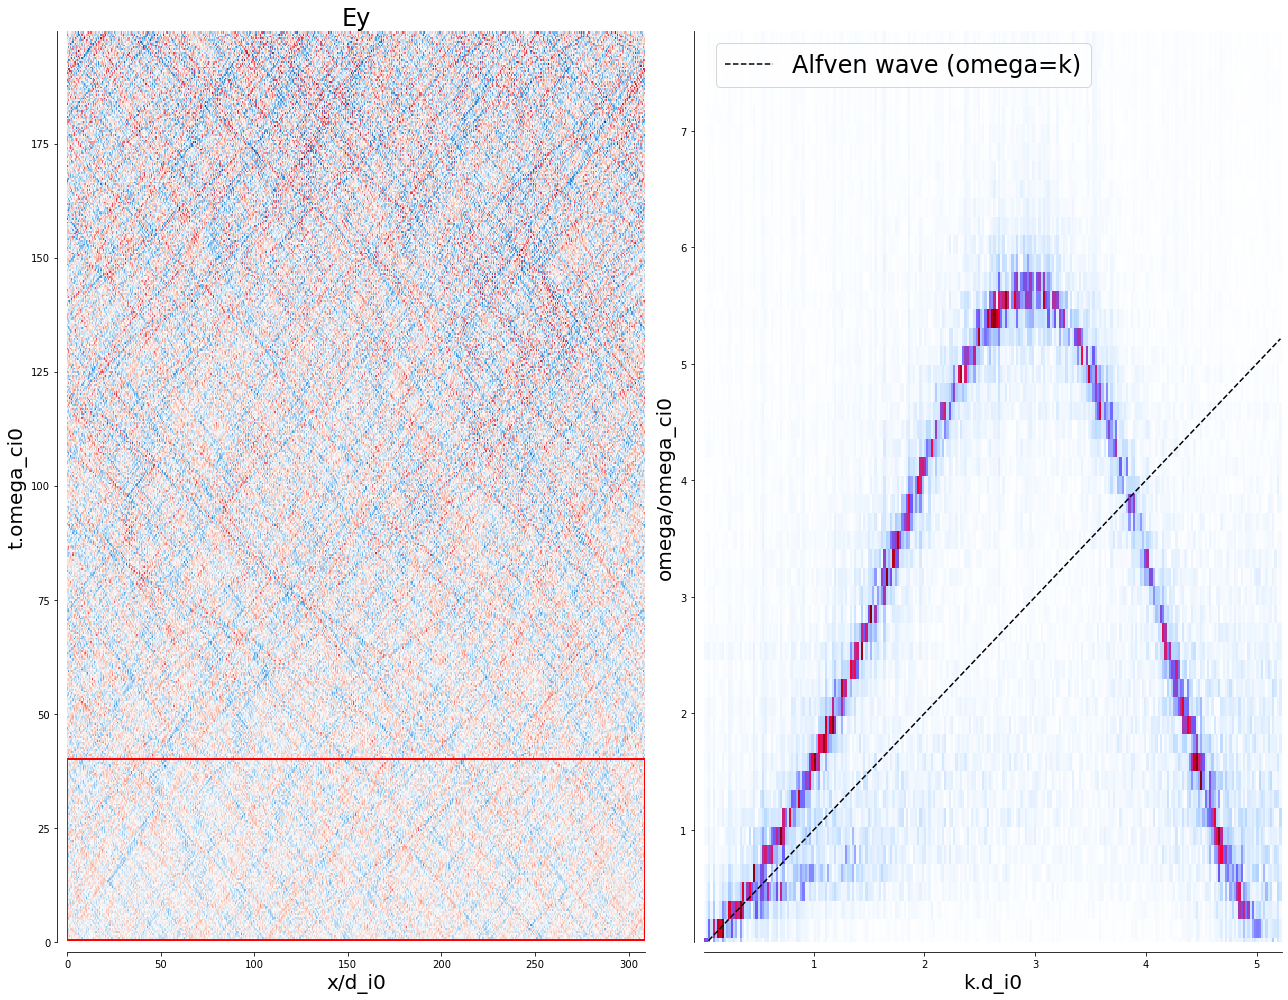

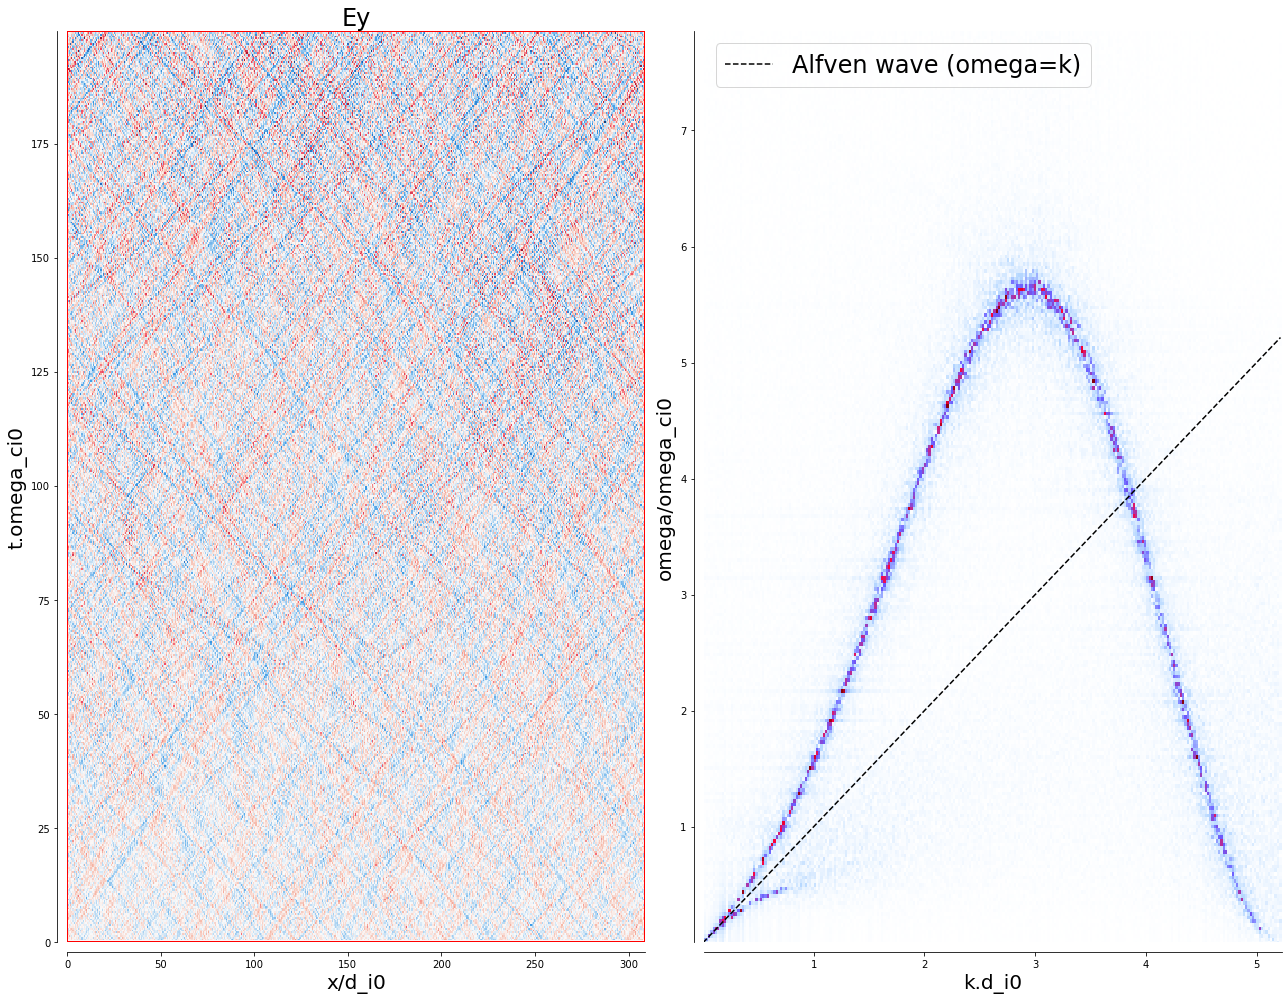

In [1]:
from leo_utils import *
import own_tools as oT
import own_colours as oC

path = '../leo'
lp = leo_param(f'{path}/src', print_param=False)
lg = leo_grid(f'{path}/products', lp)

E__t_s = np.load(f'{path}/products/E__time_space.npy')

field_omega_k_spectrum_investigate_k(E__t_s, 'Ey', lp, lg, loglog=False, time_window=[1,100])
field_omega_k_spectrum_investigate_k(E__t_s, 'Ey', lp, lg, loglog=False, time_window=[0,499])

We can select an even smaller time window, showing how "instantaneous" this wave content is.

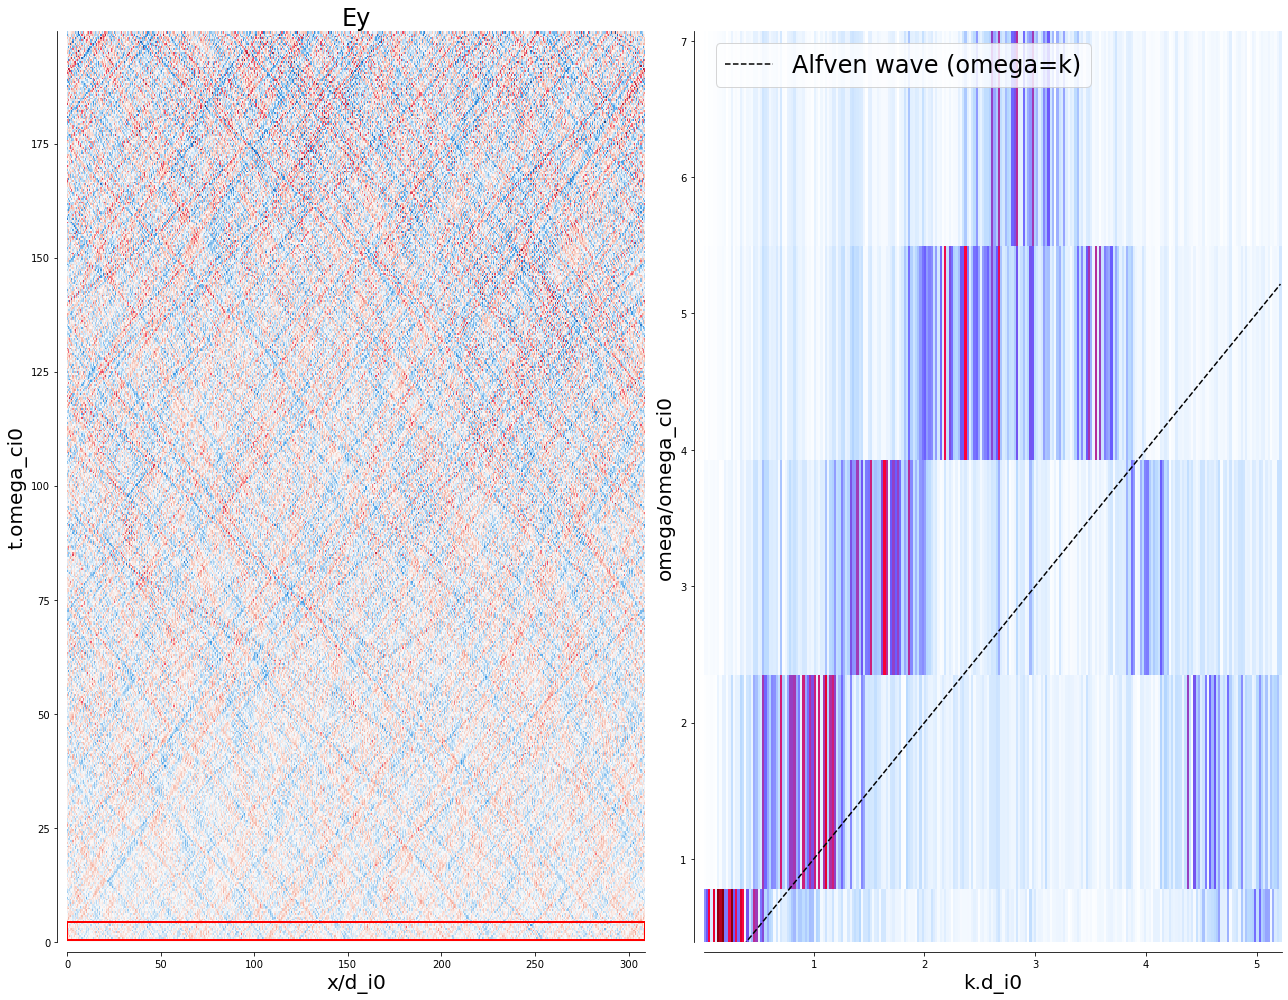

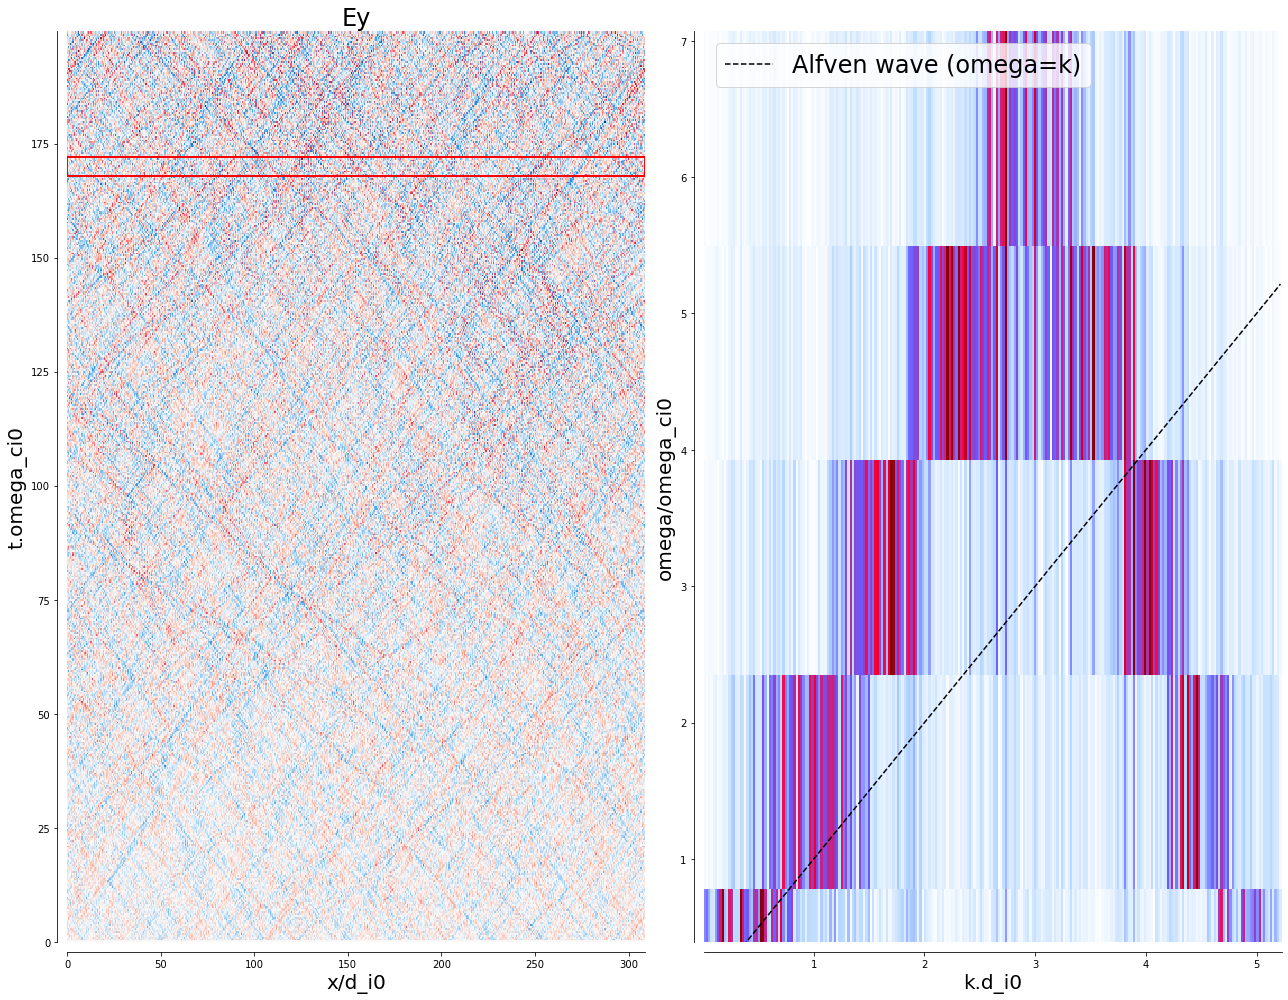

In [2]:
field_omega_k_spectrum_investigate_k(E__t_s, 'Ey', lp, lg, loglog=False, time_window=[1,11])
field_omega_k_spectrum_investigate_k(E__t_s, 'Ey', lp, lg, loglog=False, time_window=[420,430])

Finally, the electric field component is high-pass filtered along the time dimension, in order to retain only the top part of the bell, a region at high time frequencies which only seems to be filled with this branch.

In [3]:

from scipy.signal import butter, lfilter
from scipy.signal import freqz

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a


def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y


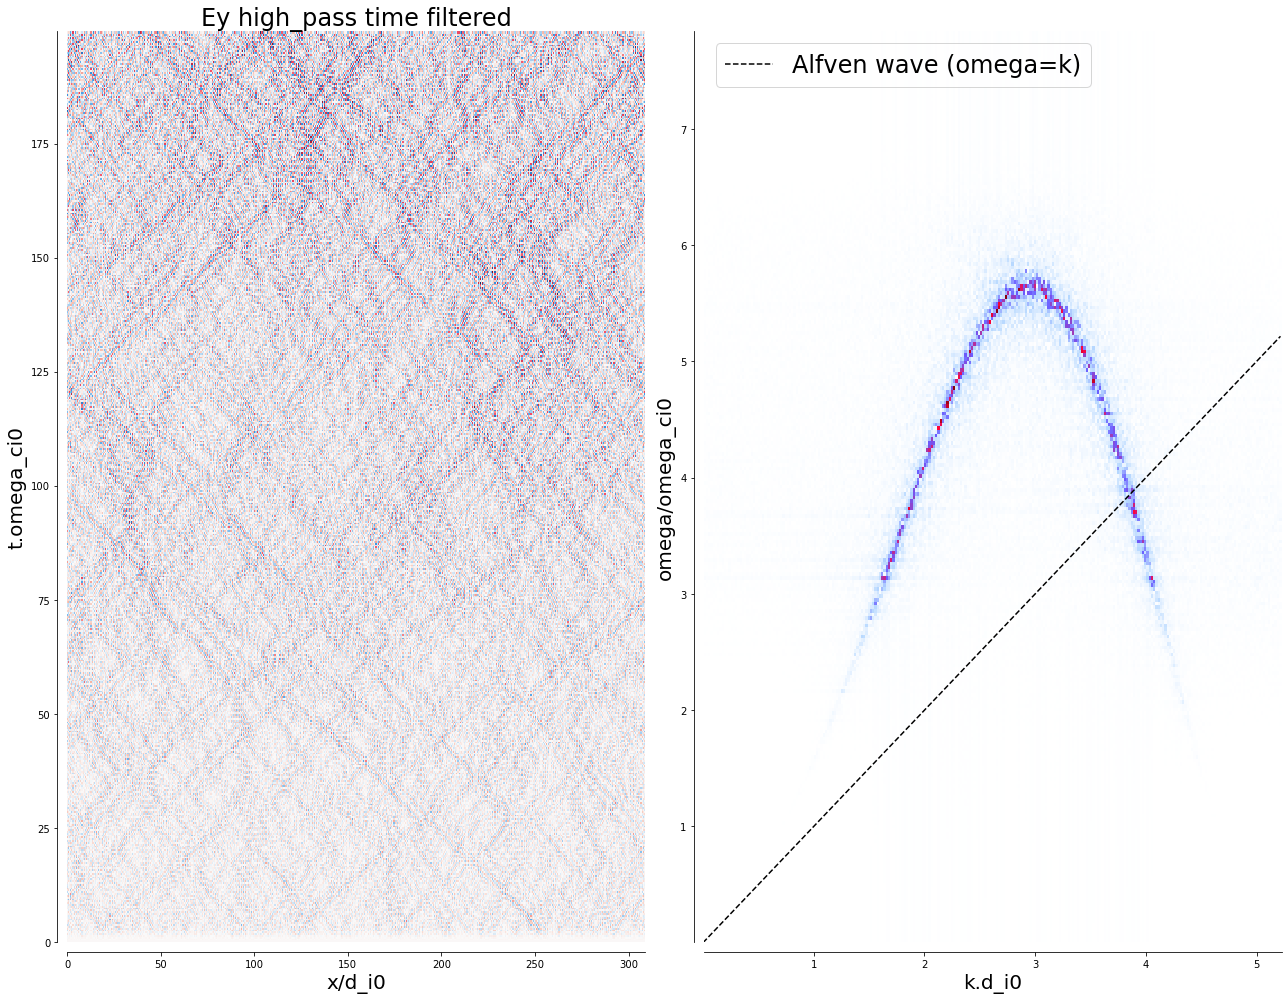

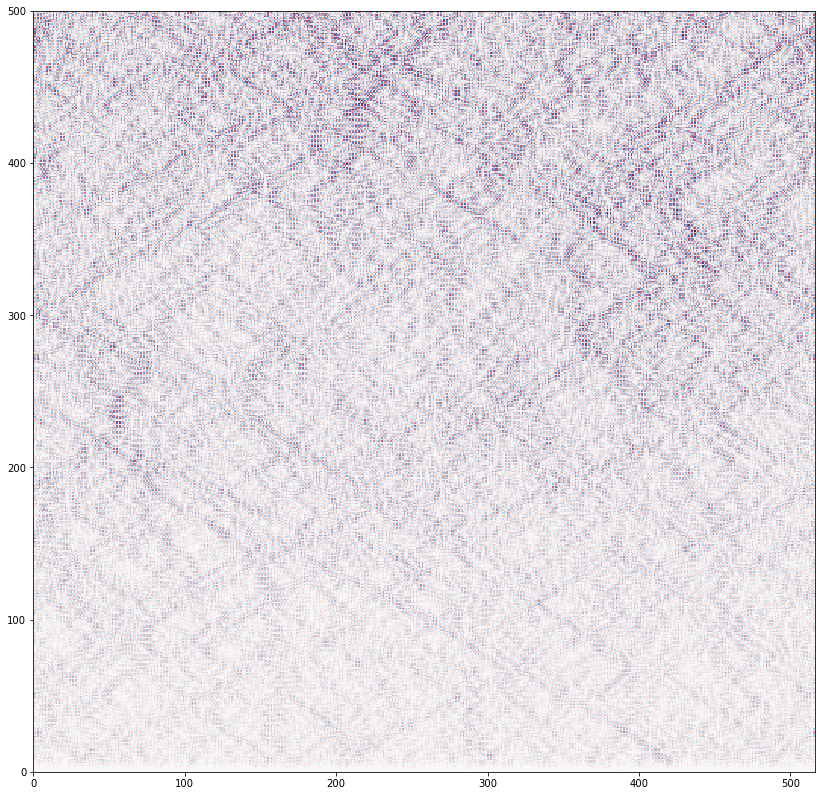

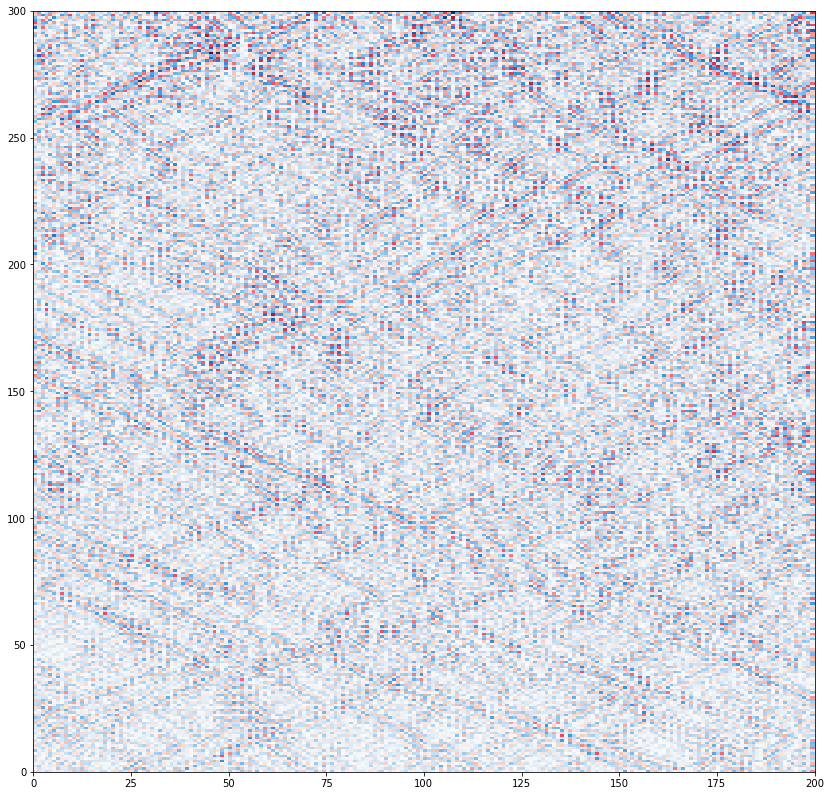

In [4]:
fs = 1/lp.dt_low
lowcut = 0.5
highcut = 0.99999

Ey = np. mean(E__t_s, axis=2)
Ey_f = np.zeros_like(Ey)

for ind_x in np.arange(Ey.shape[1]):
    Ey_f[:, ind_x] = butter_bandpass_filter(Ey[:, ind_x], lowcut, highcut, fs, order=4)

field_omega_k_spectrum(Ey_f, 'Ey high_pass time filtered', lp, lg, loglog=False)


fig, ax = plt.subplots(figsize=(14, 14))

ax.pcolormesh(Ey_f, cmap=oC.bwr_2)

plt.show()

fig, ax = plt.subplots(figsize=(14, 14))

ax.pcolormesh(Ey_f[100:400, 100:300], cmap=oC.bwr_2)

plt.show()